In [ ]:
%pip install numpy pandas matplotlib

In [ ]:
%pip install ultralytics

  Using cached ultralytics-8.3.86-py3-none-any.whl.metadata (35 kB)
  Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached torchvision-0.21.0-cp313-cp313-win_amd64.whl.metadata (6.3 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached ultralytics_thop-2.0.14-py3-none-any.whl.metadata (9.4 kB)
Using cached ultralytics-8.3.86-py3-none-any.whl (922 kB)
Using cached opencv_python-4.11.0.86-cp37-abi3-win_amd64.whl (39.5 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached torchvision-0.21.0-cp313-cp313-win_amd64.whl (1.6 MB)
Using cached ultralytics_thop-2.0.14-py3-none-any.whl (26 kB)


In [ ]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
%pip install opencv-python-headless


image 1/1 C:\Users\CHARU GUPTA\Desktop\FloodDataset\test\damage\agri_majorareas_disastermgt_flood_clip_image001.jpg: 384x640 5 persons, 1 dog, 74.9ms
Speed: 2.6ms preprocess, 74.9ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)


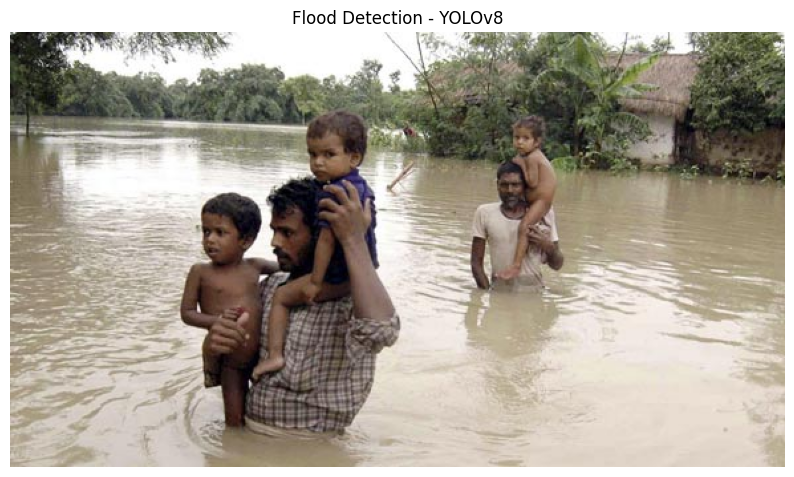

In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# Ensure YOLOv8 is installed
try:
    import ultralytics
except ImportError:
    print("Installing ultralytics...")
    %pip install ultralytics

# Load YOLOv8 model
model = YOLO("yolov8n.pt")  # Using YOLOv8 nano model

# Define the image path
image_path = r"C:\Users\CHARU GUPTA\Desktop\FloodDataset\test\damage\agri_majorareas_disastermgt_flood_clip_image001.jpg" # Change this to your image path

if not os.path.exists(image_path):
    print(f"Error: Image file {image_path} not found.")
else:
    # Perform object detection
    results = model(image_path)

    # Display results
    for result in results:
        result.show()  # Display image with bounding boxes

        # Convert image to RGB for plotting
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Plot the detected image
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title("Flood Detection - YOLOv8")
        plt.show()



image 1/1 C:\Users\CHARU GUPTA\Desktop\FloodDataset\test\damage\download3.jpg: 384x640 10 persons, 1 dog, 205.7ms
Speed: 5.2ms preprocess, 205.7ms inference, 3.2ms postprocess per image at shape (1, 3, 384, 640)


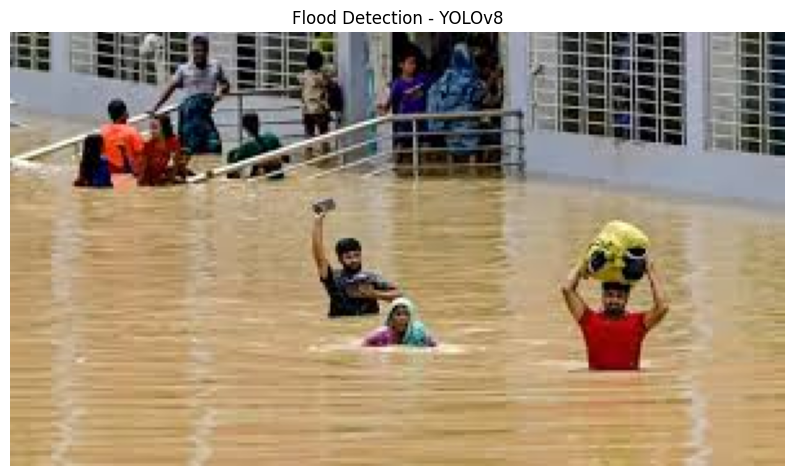

In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os


try:
    import ultralytics
except ImportError:
    print("Installing ultralytics...")
    %pip install ultralytics

model = YOLO("yolov8n.pt") 
image_path = r"C:\Users\CHARU GUPTA\Desktop\FloodDataset\test\damage\download3.jpg"  

if not os.path.exists(image_path):
    print(f"Error: Image file {image_path} not found.")
else:
    results = model(image_path)
    for result in results:
        result.show()  
        img = cv2.imread(image_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

       
        plt.figure(figsize=(10, 6))
        plt.imshow(img_rgb)
        plt.axis("off")
        plt.title("Flood Detection - YOLOv8")
        plt.show()


In [ ]:
import cv2
from ultralytics import YOLO


model = YOLO("yolov8n.pt")  
video_path = "/content/Untitled design.mp4"
output_path = "/mnt/data/output_video.mp4"


cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()


frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))


fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    
    results = model(frame)

    
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])  
            conf = box.conf[0].item() 
            cls = int(box.cls[0].item()) 
            label = f"{model.names[cls]} {conf:.2f}"

            
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

   
    out.write(frame)


cap.release()
out.release()
cv2.destroyAllWindows()

print(f"Object detection complete. Output saved to: {output_path}")


In [ ]:
from tensorflow import keras

model = keras.models.load_model(r"C:\Users\CHARU GUPTA\Desktop\HACKVERSE\model")

model.save(r"C:\Users\CHARU GUPTA\Desktop\HACKVERSE\model.h5")

print("Model successfully converted to model.h5 format.")


ValueError: File format not supported: filepath=C:\Users\CHARU GUPTA\Desktop\HACKVERSE\model. Keras 3 only supports V3 `.keras` files and legacy H5 format files (`.h5` extension). Note that the legacy SavedModel format is not supported by `load_model()` in Keras 3. In order to reload a TensorFlow SavedModel as an inference-only layer in Keras 3, use `keras.layers.TFSMLayer(C:\Users\CHARU GUPTA\Desktop\HACKVERSE\model, call_endpoint='serving_default')` (note that your `call_endpoint` might have a different name).

In [3]:
import cv2
from ultralytics import YOLO

# Load YOLOv8 model (make sure to use the correct weights)
model = YOLO("yolov8n.pt")  # You can replace with 'yolov8s.pt' or your custom-trained model

# Path to input video
video_path = r"C:\Users\CHARU GUPTA\Desktop\HACKVERSE\static\Untitled design (1).mp4"
output_path = "/mnt/data/output_video.mp4"

# Open video file
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Get video properties
frame_width = int(cap.get(3))
frame_height = int(cap.get(4))
fps = int(cap.get(cv2.CAP_PROP_FPS))

# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

# Process video frame by frame
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Perform object detection
    results = model(frame)

    # Draw bounding boxes on the frame
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # Get bounding box coordinates
            conf = box.conf[0].item()  # Confidence score
            cls = int(box.cls[0].item())  # Class index
            label = f"{model.names[cls]} {conf:.2f}"

            # Draw rectangle and label
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Write the processed frame to output video
    out.write(frame)

# Release resources
cap.release()
out.release()


print(f"Object detection complete. Output saved to: {output_path}")



0: 384x640 3 persons, 77.3ms
Speed: 6.1ms preprocess, 77.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 82.9ms
Speed: 2.1ms preprocess, 82.9ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 87.7ms
Speed: 4.7ms preprocess, 87.7ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 80.8ms
Speed: 2.2ms preprocess, 80.8ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 57.3ms
Speed: 1.9ms preprocess, 57.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 56.3ms
Speed: 1.8ms preprocess, 56.3ms inference, 3.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 63.3ms
Speed: 1.7ms preprocess, 63.3ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 56.0ms
Speed: 2.0ms preprocess, 56.0ms inference, 1.7ms postprocess per image at shape (

In [15]:
import cv2
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Path to input and output videos
video_path = r"C:\Users\CHARU GUPTA\Desktop\HACKVERSE\static\Untitled design (1).mp4"
output_path = r"C:\Users\CHARU GUPTA\Desktop\HACKVERSE\static\output_video.mp4"

# Open video file
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Error: Could not open video.")
    exit()

# Get video properties
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"Video Properties - Width: {frame_width}, Height: {frame_height}, FPS: {fps}, Total Frames: {frame_count}")

# Define the video writer
fourcc = cv2.VideoWriter_fourcc(*'XVID')
out = cv2.VideoWriter(output_path, fourcc, fps, (frame_width, frame_height))

# Check if OpenCV GUI functions are available
gui_enabled = hasattr(cv2, 'imshow')

# Process video frame by frame
frame_index = 0
while cap.isOpened():
    ret, frame = cap.read()
    
    if not ret or frame is None:
        print(f"End of video or error reading frame at index {frame_index}")
        break

    # Perform object detection
    results = model(frame)

    # Draw bounding boxes on the frame
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])  
            conf = box.conf[0].item()  
            cls = int(box.cls[0].item())  
            label = f"{model.names[cls]} {conf:.2f}"

            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
            cv2.putText(frame, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Write the processed frame to output video
    out.write(frame)

    # **Fix:** Only show frames if GUI is available
    if gui_enabled and cv2.getWindowProperty("DEEPRESCUE - Object Detection", 0) >= 0:
        cv2.imshow("DEEPRESCUE - Object Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    frame_index += 1

# Release resources
cap.release()
out.release()


print(f"✅ Object detection complete. Output saved to: {output_path}")


Video Properties - Width: 1920, Height: 1080, FPS: 30, Total Frames: 666

0: 384x640 3 persons, 62.9ms
Speed: 3.5ms preprocess, 62.9ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 76.5ms
Speed: 2.3ms preprocess, 76.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 86.2ms
Speed: 2.9ms preprocess, 86.2ms inference, 3.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 69.5ms
Speed: 4.5ms preprocess, 69.5ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 61.3ms
Speed: 3.4ms preprocess, 61.3ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 69.6ms
Speed: 2.0ms preprocess, 69.6ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 119.1ms
Speed: 2.4ms preprocess, 119.1ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 102.2ms
Speed